## Día 1 · De los reportes de la SEC a los indicadores de rentabilidad

Notebook que acompaña al post del reto *IA aplicada a finanzas*. Descarga los estados
financieros de Walmart, Target y Costco desde la API pública de EDGAR (SEC), elige la
etiqueta XBRL correcta para cada cuenta, calcula cinco indicadores y los valida contra
el 10-K original.

**Antes de correrlo:** la SEC exige identificarse. Define la variable de entorno
`SEC_USER_AGENT` con tu nombre y correo, por ejemplo `Maria Perez maria@correo.com`.

In [1]:
import json
import os
import re
import time
from html import unescape
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import requests

# --- Identificación ante la SEC (obligatoria, máx. 10 solicitudes por segundo) ---
USER_AGENT = os.environ.get("SEC_USER_AGENT", "")
if "@" not in USER_AGENT:
    raise ValueError("Define SEC_USER_AGENT con tu nombre y correo antes de correr el notebook.")
HEADERS = {"User-Agent": USER_AGENT}

DATA = Path("../data")
RAW = DATA / "raw"          # caché local de las respuestas de la API (no se sube a git)
RAW.mkdir(parents=True, exist_ok=True)

EMPRESAS = {"WMT": "Walmart", "TGT": "Target", "COST": "Costco"}

# --- Paleta del portafolio ---
SUPERFICIE = "#fcfcfb"
TINTA, TINTA_2, TINTA_MUTED = "#0b0b0b", "#52514e", "#898781"
GRILLA, EJE = "#e1e0d9", "#c3c2b7"
COLOR = {"Walmart": "#2a78d6", "Target": "#eb6834", "Costco": "#1baf7a"}

mpl.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE, "savefig.facecolor": SUPERFICIE,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "sans-serif"],
    "font.size": 10, "text.color": TINTA, "axes.labelcolor": TINTA_2, "axes.edgecolor": EJE,
    "axes.linewidth": 0.8, "axes.titlesize": 11.5, "axes.titleweight": "600",
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": TINTA_MUTED, "ytick.color": TINTA_MUTED, "xtick.labelcolor": TINTA_2,
    "ytick.labelcolor": TINTA_2, "grid.color": GRILLA, "grid.linewidth": 0.8,
    "legend.frameon": False, "lines.linewidth": 2.0, "figure.dpi": 130, "savefig.bbox": "tight",
})


def num(x, dec=1):
    """Formato español: 1.234,5."""
    if pd.isna(x):
        return "n.d."
    return f"{x:,.{dec}f}".replace(",", "\x00").replace(".", ",").replace("\x00", ".")


def get_json(url, cache=None):
    """GET con User-Agent, pausa de cortesía y caché opcional en disco."""
    if cache and cache.exists():
        return json.loads(cache.read_text(encoding="utf-8"))
    r = requests.get(url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    time.sleep(0.2)
    if cache:
        cache.write_text(r.text, encoding="utf-8")
    return r.json()

## 1. Encontrar a cada empresa y descargar sus datos

La SEC identifica a cada empresa con un **CIK** (Central Index Key). El archivo
`company_tickers.json` traduce el ticker bursátil al CIK, y el endpoint `companyfacts`
devuelve en un solo JSON todas las cifras que la empresa ha reportado en XBRL.

In [2]:
tickers = get_json("https://www.sec.gov/files/company_tickers.json", RAW / "company_tickers.json")
CIK = {v["ticker"]: int(v["cik_str"]) for v in tickers.values() if v["ticker"] in EMPRESAS}

facts = {
    t: get_json(f"https://data.sec.gov/api/xbrl/companyfacts/CIK{CIK[t]:010d}.json",
                RAW / f"companyfacts_{t}.json")
    for t in EMPRESAS
}
pd.DataFrame({"Empresa": [EMPRESAS[t] for t in EMPRESAS],
              "Ticker": list(EMPRESAS),
              "CIK": [CIK[t] for t in EMPRESAS],
              "Etiquetas us-gaap reportadas": [len(facts[t]["facts"]["us-gaap"]) for t in EMPRESAS]})

,Empresa,Ticker,CIK,Etiquetas us-gaap reportadas
0,Walmart,WMT,104169,478
1,Target,TGT,27419,528
2,Costco,COST,909832,460


## 2. Extraer series anuales sin mezclar períodos

Cada 10-K trae la cifra del año y las comparativas de años anteriores, y una cifra puede
reaparecer corregida en un 10-K posterior. La función `serie_anual` se queda solo con
datos de 10-K, en dólares, y para las cuentas de flujo (ingresos, utilidad) exige que el
período dure un año, entre 350 y 380 días. Así descarta trimestres sueltos y acepta los
años fiscales de 53 semanas. Si una misma fecha de cierre aparece varias veces, gana la
presentación más reciente.

In [3]:
def serie_anual(ticker, etiqueta, flujo):
    """Serie anual de una etiqueta us-gaap: una fila por fecha de cierre."""
    datos = facts[ticker]["facts"]["us-gaap"].get(etiqueta, {}).get("units", {}).get("USD", [])
    df = pd.DataFrame(datos)
    if df.empty:
        return df
    df = df[df["form"].isin(["10-K", "10-K/A"])].copy()
    df["end"] = pd.to_datetime(df["end"])
    if flujo:
        df["start"] = pd.to_datetime(df["start"])
        dias = (df["end"] - df["start"]).dt.days
        df = df[dias.between(350, 380)]
    return (df.sort_values("filed")
              .drop_duplicates("end", keep="last")
              .sort_values("end")[["end", "val", "filed", "accn"]]
              .reset_index(drop=True))

## 3. La trampa: la etiqueta "obvia" no siempre es la vigente

Un primer intento natural, y el que suele proponer un asistente de IA si no se le da
contexto, es pedir la etiqueta `Revenues` a las tres empresas. La tabla muestra hasta qué
fecha llega esa etiqueta en cada caso.

In [4]:
#| label: tbl-trampa
filas = []
for t, nombre in EMPRESAS.items():
    s = serie_anual(t, "Revenues", flujo=True)
    filas.append({"Empresa": nombre,
                  "Último cierre con 'Revenues'": s["end"].max().strftime("%Y-%m"),
                  "Valor (miles de millones USD)": num(s["val"].iloc[-1] / 1e9)})
pd.DataFrame(filas).style.hide(axis="index")

Empresa,Último cierre con 'Revenues',Valor (miles de millones USD)
Walmart,2026-01,"713,2"
Target,2015-01,"72,6"
Costco,2025-08,"275,2"


Target dejó de usar `Revenues` en 2015 y desde entonces reporta sus ventas como
`RevenueFromContractWithCustomerExcludingAssessedTax`. El código ingenuo no falla: devuelve
un número, solo que es de hace diez años. Es el tipo de error que no se ve si nadie
revisa la fecha.

## 4. Elegir la etiqueta correcta para cada cuenta

La regla: para cada cuenta hay una lista de etiquetas candidatas en orden de preferencia,
y se elige la primera **que llega al último año fiscal de la empresa**, no la primera que
existe. Para el pasivo total hay un problema adicional: Walmart y Target no reportan la
etiqueta `Liabilities`, así que se calcula como pasivo y patrimonio total menos
patrimonio total (incluida la participación no controladora).

In [5]:
CANDIDATAS = {
    "ingresos": (True, ["Revenues", "RevenueFromContractWithCustomerExcludingAssessedTax", "SalesRevenueNet"]),
    "utilidad_neta": (True, ["NetIncomeLoss"]),
    "activos": (False, ["Assets"]),
    "patrimonio": (False, ["StockholdersEquity"]),
    "patrimonio_total": (False, ["StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest",
                                 "StockholdersEquity"]),
    "pasivo_y_patrimonio": (False, ["LiabilitiesAndStockholdersEquity"]),
    "activo_corriente": (False, ["AssetsCurrent"]),
    "pasivo_corriente": (False, ["LiabilitiesCurrent"]),
}

ultimo_cierre = {t: serie_anual(t, "Assets", flujo=False)["end"].max() for t in EMPRESAS}

elegidas, base = [], []
for t, nombre in EMPRESAS.items():
    for cuenta, (flujo, etiquetas) in CANDIDATAS.items():
        for etiqueta in etiquetas:
            s = serie_anual(t, etiqueta, flujo)
            if not s.empty and s["end"].max() == ultimo_cierre[t]:
                break
        else:
            raise ValueError(f"{nombre}: ninguna etiqueta de '{cuenta}' llega al último cierre")
        elegidas.append({"Empresa": nombre, "Cuenta": cuenta, "Etiqueta XBRL": etiqueta})
        base.append(s.assign(empresa=nombre, ticker=t, cuenta=cuenta, etiqueta=etiqueta))

base = pd.concat(base, ignore_index=True)

In [6]:
#| label: tbl-mapa
# Espacio invisible antes de cada mayúscula: las etiquetas largas pueden partirse en pantallas angostas
partible = lambda etiqueta: re.sub(r"(?<=[a-z])(?=[A-Z])", "\u200b", etiqueta)
(pd.DataFrame(elegidas)
   .assign(**{"Etiqueta XBRL": lambda d: d["Etiqueta XBRL"].map(partible)})
   .pivot(index="Cuenta", columns="Empresa", values="Etiqueta XBRL")
   .loc[list(CANDIDATAS), list(EMPRESAS.values())]
   .style.set_properties(**{"font-size": "0.82em"}))

Empresa,Walmart,Target,Costco
Cuenta,,,
ingresos,Revenues,Revenue​From​Contract​With​Customer​Excluding​Assessed​Tax,Revenues
utilidad_neta,Net​Income​Loss,Net​Income​Loss,Net​Income​Loss
activos,Assets,Assets,Assets
patrimonio,Stockholders​Equity,Stockholders​Equity,Stockholders​Equity
patrimonio_total,Stockholders​Equity​Including​Portion​Attributable​To​Noncontrolling​Interest,Stockholders​Equity,Stockholders​Equity​Including​Portion​Attributable​To​Noncontrolling​Interest
pasivo_y_patrimonio,Liabilities​And​Stockholders​Equity,Liabilities​And​Stockholders​Equity,Liabilities​And​Stockholders​Equity
activo_corriente,Assets​Current,Assets​Current,Assets​Current
pasivo_corriente,Liabilities​Current,Liabilities​Current,Liabilities​Current


## 5. Calcular los indicadores

| Indicador | Fórmula | Qué mide |
|---|---|---|
| Margen neto | utilidad neta / ingresos | cuánto queda de cada dólar vendido |
| ROA | utilidad neta / activos promedio | rentabilidad de todo lo que la empresa usa para operar |
| ROE | utilidad neta / patrimonio promedio | rentabilidad del capital de los accionistas |
| Razón corriente | activo corriente / pasivo corriente | holgura para pagar obligaciones de corto plazo |
| Pasivo / patrimonio | pasivo total / patrimonio total | cuánto se financia con terceros por cada dólar propio |

ROA y ROE usan el **promedio** del saldo inicial y final: la utilidad se genera durante
todo el año, así que se compara contra el capital promedio del año y no contra la foto
del cierre. La utilidad neta es la atribuible a la controladora (`NetIncomeLoss`), por
eso el ROE usa el patrimonio de la controladora y no el total.

El pasivo total incluye arrendamientos, proveedores y otras obligaciones, no solo deuda
financiera. Se usa porque es la única definición que se puede construir igual para las
tres empresas con lo que reportan en XBRL.

In [7]:
anchos = (base.pivot_table(index=["empresa", "end"], columns="cuenta", values="val")
              .reset_index().sort_values(["empresa", "end"]))

g = anchos.groupby("empresa")
anchos["activos_prom"] = (anchos["activos"] + g["activos"].shift()) / 2
anchos["patrimonio_prom"] = (anchos["patrimonio"] + g["patrimonio"].shift()) / 2
anchos["pasivo_total"] = anchos["pasivo_y_patrimonio"] - anchos["patrimonio_total"]

anchos["margen_neto"] = anchos["utilidad_neta"] / anchos["ingresos"]
anchos["roa"] = anchos["utilidad_neta"] / anchos["activos_prom"]
anchos["roe"] = anchos["utilidad_neta"] / anchos["patrimonio_prom"]
anchos["razon_corriente"] = anchos["activo_corriente"] / anchos["pasivo_corriente"]
anchos["pasivo_patrimonio"] = anchos["pasivo_total"] / anchos["patrimonio_total"]

# Últimos cinco años fiscales completos de cada empresa
indicadores = (anchos.dropna(subset=["ingresos", "utilidad_neta", "activos_prom"])
                     .groupby("empresa").tail(5).reset_index(drop=True))
indicadores = indicadores.rename(columns={"empresa": "Empresa", "end": "cierre_fiscal"})

In [8]:
#| label: tbl-indicadores
ultimo = indicadores.groupby("Empresa").tail(1).set_index("Empresa").loc[list(EMPRESAS.values())]
pd.DataFrame({
    "Cierre fiscal": ultimo["cierre_fiscal"].dt.strftime("%Y-%m"),
    "Ingresos (mil M USD)": ultimo["ingresos"].map(lambda v: num(v / 1e9)),
    "Margen neto": ultimo["margen_neto"].map(lambda v: num(v * 100) + " %"),
    "ROA": ultimo["roa"].map(lambda v: num(v * 100) + " %"),
    "ROE": ultimo["roe"].map(lambda v: num(v * 100) + " %"),
    "Razón corriente": ultimo["razon_corriente"].map(lambda v: num(v, 2)),
    "Pasivo / patrimonio": ultimo["pasivo_patrimonio"].map(lambda v: num(v, 2)),
})

,Cierre fiscal,Ingresos (mil M USD),Margen neto,ROA,ROE,Razón corriente,Pasivo / patrimonio
Empresa,,,,,,,
Walmart,2026-01,"713,2","3,1 %","8,0 %","23,0 %","0,79","1,69"
Target,2026-01,"104,8","3,5 %","6,3 %","24,0 %","0,94","2,68"
Costco,2025-08,"275,2","2,9 %","11,0 %","30,7 %","1,03","1,64"


Los cierres no coinciden: Walmart y Target cierran a fines de enero y Costco a fines de
agosto. Comparar "el último año" de cada una es comparar períodos desplazados unos cinco
meses. El gráfico usa la fecha real de cierre en el eje horizontal para que el desfase se
vea en lugar de esconderse detrás de una etiqueta de año.

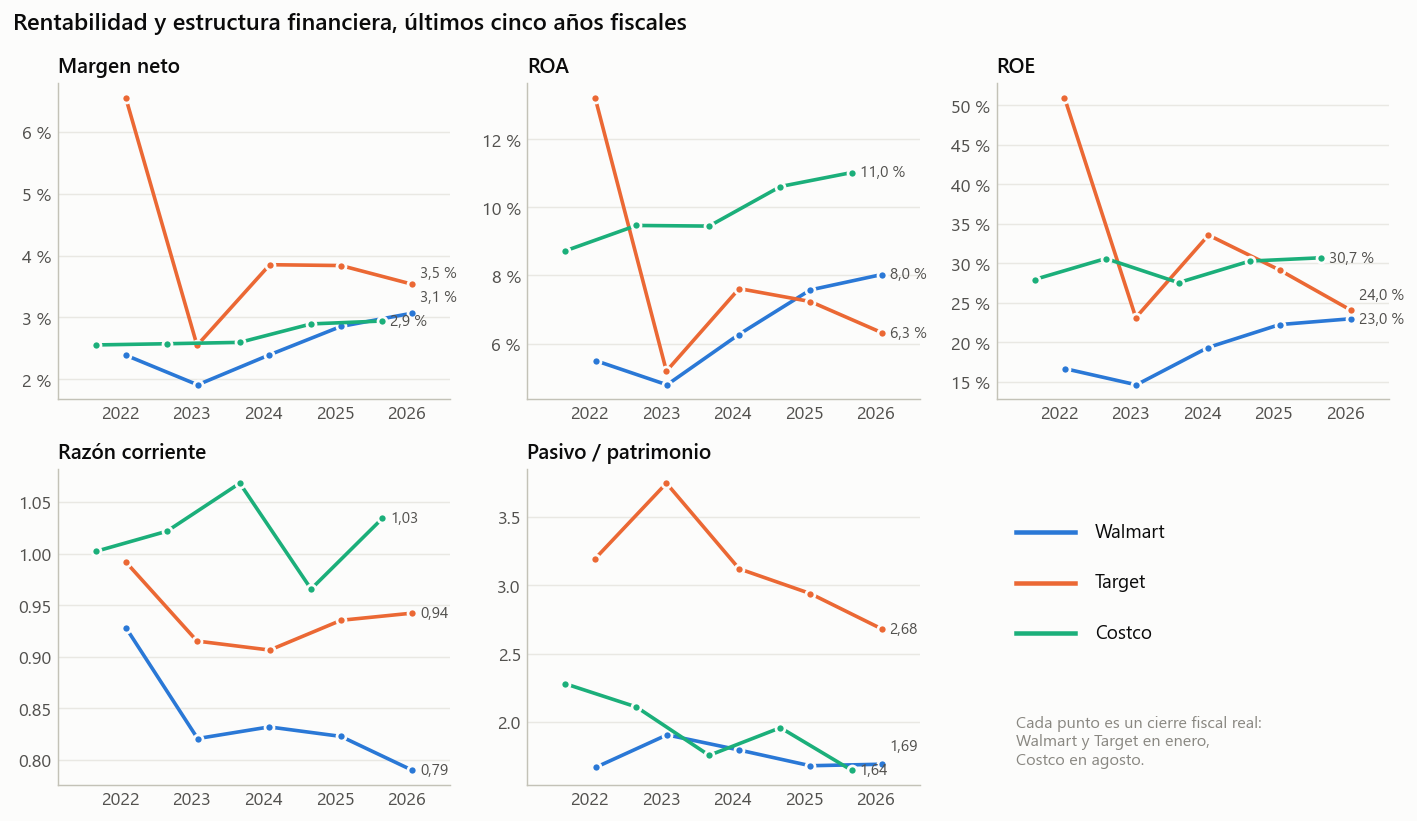

In [9]:
#| label: fig-indicadores
paneles = [("margen_neto", "Margen neto", True), ("roa", "ROA", True), ("roe", "ROE", True),
           ("razon_corriente", "Razón corriente", False), ("pasivo_patrimonio", "Pasivo / patrimonio", False)]

fig, ejes = plt.subplots(2, 3, figsize=(11, 6.4))
for ax, (col, titulo, pct) in zip(ejes.flat, paneles):
    finales = []
    for nombre in EMPRESAS.values():
        d = indicadores[indicadores["Empresa"] == nombre]
        y = d[col] * (100 if pct else 1)
        ax.plot(d["cierre_fiscal"], y, color=COLOR[nombre], marker="o", markersize=5,
                markeredgecolor=SUPERFICIE, markeredgewidth=1.5, label=nombre)
        finales.append([y.iloc[-1], d["cierre_fiscal"].iloc[-1], y.iloc[-1]])
    # Etiquetas al final de cada línea, separadas si quedan demasiado cerca
    lo, hi = ax.get_ylim()
    separacion = (hi - lo) * 0.075
    finales.sort()
    for i in range(1, len(finales)):
        finales[i][0] = max(finales[i][0], finales[i - 1][0] + separacion)
    for y_txt, x, y_val in finales:
        ax.text(mdates.date2num(x) + 40, y_txt, num(y_val, 1 if pct else 2) + (" %" if pct else ""),
                va="center", fontsize=8.5, color=TINTA_2)
    ax.set_title(titulo)
    ax.yaxis.grid(True, alpha=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.margins(x=0.12)
    if pct:
        ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f} %")

leyenda = ejes.flat[5]
leyenda.axis("off")
for i, nombre in enumerate(EMPRESAS.values()):
    leyenda.plot([0.05, 0.2], [0.8 - i * 0.16] * 2, color=COLOR[nombre], linewidth=2.5)
    leyenda.text(0.25, 0.8 - i * 0.16, nombre, va="center", fontsize=10.5)
leyenda.text(0.05, 0.22, "Cada punto es un cierre fiscal real:\nWalmart y Target en enero,\nCostco en agosto.",
             fontsize=9, color=TINTA_MUTED, va="top")
leyenda.set_xlim(0, 1); leyenda.set_ylim(0, 1)

fig.suptitle("Rentabilidad y estructura financiera, últimos cinco años fiscales",
             x=0.01, ha="left", fontsize=13, fontweight="600")
fig.tight_layout()
plt.show()

## 6. Validar antes de creer

Tres controles automáticos y uno contra el documento original:

1. **Identidad contable.** Activos debe ser igual a pasivo más patrimonio en cada cierre.
2. **Pasivo calculado contra pasivo reportado.** Costco sí reporta `Liabilities`, así que
   sirve para comprobar que la fórmula usada para Walmart y Target es correcta.
3. **Cobertura.** Todos los indicadores deben existir para los cinco años de cada empresa.
4. **Contra el 10-K.** Se descarga el 10-K más reciente de cada empresa y se busca en el
   texto la utilidad neta y los ingresos, en millones, tal como aparecen en el estado de
   resultados.

In [10]:
#| label: out-controles
# Ventana del análisis: los cinco cierres más el anterior, que entra en los promedios
inicio = indicadores.groupby("Empresa")["cierre_fiscal"].min() - pd.DateOffset(years=1, days=10)
en_ventana = anchos["end"] >= anchos["empresa"].map(inicio)
descuadre = (anchos["activos"] - anchos["pasivo_y_patrimonio"]).abs()

costco_liab = serie_anual("COST", "Liabilities", flujo=False).set_index("end")["val"]
costco_calc = anchos[anchos["empresa"] == "Costco"].set_index("end")["pasivo_total"]
dif_pasivo = (costco_liab - costco_calc).dropna().abs().max()

cobertura = indicadores.groupby("Empresa")[["margen_neto", "roa", "roe", "razon_corriente",
                                             "pasivo_patrimonio"]].count().min().min()

print(f"1. Descuadre máximo activos vs pasivo + patrimonio en la ventana: {num(descuadre[en_ventana].max() / 1e6, 0)} millones USD")
print(f"2. Diferencia máxima pasivo Costco reportado vs calculado: {num(dif_pasivo / 1e6, 0)} millones USD")
print(f"3. Años con todos los indicadores, mínimo por empresa: {cobertura}")

fuera = anchos[~en_ventana & (descuadre > 0)]
for _, f in fuera.iterrows():
    print(f"   Fuera de la ventana: {f['empresa']} {f['end']:%Y-%m} descuadra {num(descuadre[_] / 1e6, 0)} millones USD")

1. Descuadre máximo activos vs pasivo + patrimonio en la ventana: 0 millones USD
2. Diferencia máxima pasivo Costco reportado vs calculado: 0 millones USD
3. Años con todos los indicadores, mínimo por empresa: 5
   Fuera de la ventana: Costco 2014-08 descuadra 362 millones USD
   Fuera de la ventana: Walmart 2014-01 descuadra 210 millones USD


Los descuadres fuera de la ventana no son errores de la SEC: son **cifras ajustadas hacia
atrás**. Cuando un 10-K posterior vuelve a presentar un año anterior con otro valor (por
una corrección o por un cambio de norma contable aplicado retroactivamente), la API
guarda las dos versiones. Como
`serie_anual` se queda con la presentación más reciente de cada etiqueta por separado, en
esos años el activo sale del documento corregido y el pasivo más patrimonio del original.
Para un análisis histórico largo habría que tomar todas las cuentas de un año desde el
mismo documento.

In [11]:
#| label: tbl-validacion
def texto_10k(ticker):
    """Texto plano del 10-K más reciente y su URL."""
    sub = get_json(f"https://data.sec.gov/submissions/CIK{CIK[ticker]:010d}.json")
    rec = pd.DataFrame(sub["filings"]["recent"])
    fila = rec[rec["form"] == "10-K"].iloc[0]
    url = (f"https://www.sec.gov/Archives/edgar/data/{CIK[ticker]}/"
           f"{fila['accessionNumber'].replace('-', '')}/{fila['primaryDocument']}")
    cache = RAW / f"10k_{ticker}.htm"
    if not cache.exists():
        cache.write_bytes(requests.get(url, headers=HEADERS, timeout=60).content)
        time.sleep(0.2)
    html = cache.read_text(encoding="utf-8", errors="ignore")
    return re.sub(r"\s+", " ", unescape(re.sub(r"<[^>]+>", " ", html))), url, fila["reportDate"]

filas = []
for t, nombre in EMPRESAS.items():
    texto, url, cierre_10k = texto_10k(t)
    u = ultimo.loc[nombre]
    for cuenta in ["ingresos", "utilidad_neta"]:
        en_millones = f"{round(u[cuenta] / 1e6):,}"
        filas.append({"Empresa": nombre, "Cierre 10-K": cierre_10k, "Cuenta": cuenta,
                      "Valor API (millones)": en_millones,
                      "¿Aparece en el 10-K?": "sí" if en_millones in texto else "revisar a mano",
                      "Documento": url})
validacion = pd.DataFrame(filas)
validacion.drop(columns="Documento").style.hide(axis="index")

Empresa,Cierre 10-K,Cuenta,Valor API (millones),¿Aparece en el 10-K?
Walmart,2026-01-31,ingresos,"713,163",sí
Walmart,2026-01-31,utilidad_neta,"21,893",sí
Target,2026-01-31,ingresos,"104,780",sí
Target,2026-01-31,utilidad_neta,"3,705",sí
Costco,2025-08-31,ingresos,"275,235",sí
Costco,2025-08-31,utilidad_neta,"8,099",sí


## 7. Guardar los resultados

Dos archivos alimentan el resto del reto:

- `datos_base.csv`: las cifras originales en formato largo, con la etiqueta XBRL, la fecha
  de presentación y el número de acceso de la SEC de cada dato, para poder rastrearlo.
- `indicadores.csv`: una fila por empresa y cierre fiscal, con las cuentas y los cinco
  indicadores.

In [12]:
(base.rename(columns={"end": "cierre_fiscal", "val": "valor_usd", "filed": "fecha_presentacion",
                      "accn": "numero_acceso"})
     [["empresa", "ticker", "cuenta", "etiqueta", "cierre_fiscal", "valor_usd",
       "fecha_presentacion", "numero_acceso"]]
     .to_csv(DATA / "datos_base.csv", index=False))

columnas = ["Empresa", "cierre_fiscal", "ingresos", "utilidad_neta", "activos", "patrimonio",
            "pasivo_total", "activo_corriente", "pasivo_corriente", "margen_neto", "roa", "roe",
            "razon_corriente", "pasivo_patrimonio"]
indicadores[columnas].rename(columns={"Empresa": "empresa"}).to_csv(DATA / "indicadores.csv", index=False)
validacion.to_csv(DATA / "validacion_10k.csv", index=False)
print(f"Guardados {len(base)} datos base y {len(indicadores)} filas de indicadores en {DATA}")

Guardados 413 datos base y 15 filas de indicadores en ..\data
